# Introduction to text embeddings on S&P 500 news

objectives# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Retrieve Financial News:**
   - Use the `yfinance` library to gather news headlines for all companies in the S&P 500 index.

2. **Clean and Structure Financial Text Data:**
   - Extract and organize relevant metadata (e.g., ticker, title, summary, publication date, URL) into a structured pandas DataFrame.

3. **Generate Text Embeddings:**
   - Apply a pre-trained sentence transformer model (`all-MiniLM-L6-v2`) to convert news headlines and summaries into numerical embeddings.

4. **Apply Clustering Techniques:**
   - Use K-Means clustering to identify groups of similar news articles based on semantic content.

5. **Determine Optimal Number of Clusters:**
   - Evaluate clustering quality using silhouette scores to find the best number of clusters.

6. **Visualize High-Dimensional Embeddings:**
   - Reduce the embedding space using PCA and visualize clusters in two dimensions.

7. **Interpret Cluster Themes:**
   - Analyze representative news


## Install and Import important librairies

In [1]:
%pip install pandas
%pip install yfinance
%pip install lxml
%pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 10.1 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.6.0
    Uninstalling sentence-transformers-5.6.0:
      Successfully uninstalled sentence-transformers-5.6.0


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

## Get the list of stocks in the S&P 500

In [3]:
import requests

# Read and print the stock tickers that make up S&P500
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', headers=headers)
df_tickers = pd.read_html(response.content)[0]

display(df_tickers.head())

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [4]:
ticker_list = df_tickers['Symbol'].tolist()

## Get the news of all 500 stocks in the S&P 500 Index
Use the yfinance library to retrieve the news of all 500 stocks in the index.
https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html

### Get the news in a dictionary

In [5]:
import time

# Yahoo Finance tickers use '-' instead of '.' (e.g., BRK.B -> BRK-B)
yf_ticker_list = [t.replace('.', '-') for t in ticker_list]

news_dict = {}

for i, ticker in enumerate(yf_ticker_list):
    try:
        stock = yf.Ticker(ticker)
        news_dict[ticker] = stock.news
    except Exception as e:
        print(f"Could not retrieve news for {ticker}: {e}")
        news_dict[ticker] = []

    # Print progress and pause briefly every 50 tickers to be polite to the API
    if i % 50 == 0:
        print(f"Retrieved news for {i}/{len(yf_ticker_list)} tickers...")
        time.sleep(1)

print(f"\nFinished retrieving news for {len(news_dict)} tickers.")
print(f"Example - number of articles for {yf_ticker_list[0]}: {len(news_dict[yf_ticker_list[0]])}")

Retrieved news for 0/503 tickers...
Retrieved news for 50/503 tickers...
Retrieved news for 100/503 tickers...
Retrieved news for 150/503 tickers...
Retrieved news for 200/503 tickers...
Retrieved news for 250/503 tickers...
Retrieved news for 300/503 tickers...
Retrieved news for 350/503 tickers...
Retrieved news for 400/503 tickers...
Retrieved news for 450/503 tickers...


ERROR:yfinance:WM: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WAT: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WEC: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WFC: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WELL: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WST: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WDC: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WY: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WSM: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WMB: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WTW: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:WDAY: Failed to retrieve the news and re

Retrieved news for 500/503 tickers...


ERROR:yfinance:ZBH: Failed to retrieve the news and received faulty response instead.
ERROR:yfinance:ZTS: Failed to retrieve the news and received faulty response instead.



Finished retrieving news for 503 tickers.
Example - number of articles for MMM: 10


### Structure the news into a pandas dataframe

Your final dataframe should have the following columns:
- TICKER
- TITLE (of the news)
- SUMMARY (of the news)
- PUBLICATION_DATE (of the news)
- URL (of the news)

Note: all of those fields are provided in the yfinance news component. Refer to the library documentation.

In [6]:
def parse_news_item(ticker, item):
    """
    Extract TICKER, TITLE, SUMMARY, PUBLICATION_DATE, URL and PROVIDER from
    a single yfinance news item. Handles both the newer schema (fields
    nested under 'content') and the older flat schema.
    """
    content = item.get('content', item)

    title = content.get('title', '')
    summary = content.get('summary', content.get('description', ''))
    pub_date = content.get('pubDate', content.get('providerPublishTime', ''))

    url = ''
    canonical = content.get('canonicalUrl')
    if isinstance(canonical, dict):
        url = canonical.get('url', '')
    if not url:
        url = content.get('link', '')

    provider = content.get('provider')
    if isinstance(provider, dict):
        provider_name = provider.get('displayName', '')
    else:
        provider_name = content.get('publisher', '')

    return {
        'TICKER': ticker,
        'TITLE': title,
        'SUMMARY': summary,
        'PUBLICATION_DATE': pub_date,
        'URL': url,
        'PROVIDER': provider_name
    }


records = []
for ticker, news_list in news_dict.items():
    for item in news_list:
        records.append(parse_news_item(ticker, item))

df_news = pd.DataFrame(
    records,
    columns=['TICKER', 'TITLE', 'SUMMARY', 'PUBLICATION_DATE', 'URL', 'PROVIDER']
)

# Basic cleaning: strip whitespace, drop empty titles, drop duplicate
# (ticker, title) pairs
df_news['TITLE'] = df_news['TITLE'].str.strip()
df_news = df_news[df_news['TITLE'] != '']
df_news = df_news.drop_duplicates(subset=['TICKER', 'TITLE']).reset_index(drop=True)

print(f"Final news DataFrame shape: {df_news.shape}")
display(df_news.head())

Final news DataFrame shape: (4830, 6)


,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,PROVIDER
0,MMM,"Industrial Giant Sees Insider Selling, Accordi...",Kevin H. Rhodes exercised options at $154.69 p...,2026-07-31T22:40:01Z,https://www.fool.com/coverage/filings/2026/07/...,Motley Fool
1,MMM,CSL Q2 Earnings Beat Estimates on Record Sales...,Carlisle tops Q2 earnings and revenue estimate...,2026-07-30T15:38:00Z,https://finance.yahoo.com/markets/stocks/artic...,Zacks
2,MMM,Five Below and Whirlpool have been highlighted...,Five Below delivered strong sales growth and r...,2026-07-30T12:48:00Z,https://finance.yahoo.com/markets/stocks/artic...,Zacks
3,MMM,Buy These 3 Blue-Chip Stocks After Strong Q2 2...,"MMM, TRV and UNH posted strong Q2 results, wit...",2026-07-29T13:06:00Z,https://finance.yahoo.com/markets/stocks/artic...,Zacks
4,MMM,"Beat the Market Like Zacks: Monster Beverage, ...","MNST, CRS and USIO highlight Zacks strategies ...",2026-07-27T12:15:00Z,https://finance.yahoo.com/markets/stocks/artic...,Zacks


## Exploring text embeddings

- Use the open-source model: 'sentence-transformers/all-MiniLM-L6-v2' to create embeddings on the news title and summary
- Add a column to your news dataframe called EMBEDDED_TEXT using ONLY the TITLE of the news
- Add a column to your news dataframe called EMBEDDINGS, which contains the embedding of EMBEDDED_TEXT


In [7]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Use ONLY the title of the news as the text to embed
df_news['EMBEDDED_TEXT'] = df_news['TITLE']

# Encode all titles in a single batched call for efficiency
embedding_matrix = model.encode(
    df_news['EMBEDDED_TEXT'].tolist(),
    show_progress_bar=True,
    batch_size=64
)

df_news['EMBEDDINGS'] = list(embedding_matrix)

print(f"Embedding dimension: {embedding_matrix.shape[1]}")
display(df_news[['TICKER', 'TITLE', 'EMBEDDED_TEXT', 'EMBEDDINGS']].head())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/76 [00:00<?, ?it/s]

Embedding dimension: 384


,TICKER,TITLE,EMBEDDED_TEXT,EMBEDDINGS
0,MMM,"Industrial Giant Sees Insider Selling, Accordi...","Industrial Giant Sees Insider Selling, Accordi...","[0.008484298, -0.06413272, 0.033066258, -0.021..."
1,MMM,CSL Q2 Earnings Beat Estimates on Record Sales...,CSL Q2 Earnings Beat Estimates on Record Sales...,"[-0.070331186, 0.041927982, 0.036602825, 0.104..."
2,MMM,Five Below and Whirlpool have been highlighted...,Five Below and Whirlpool have been highlighted...,"[-0.05339533, 0.020455604, 0.033223037, 0.0309..."
3,MMM,Buy These 3 Blue-Chip Stocks After Strong Q2 2...,Buy These 3 Blue-Chip Stocks After Strong Q2 2...,"[-0.056994054, -0.031063482, -0.022163516, -0...."
4,MMM,"Beat the Market Like Zacks: Monster Beverage, ...","Beat the Market Like Zacks: Monster Beverage, ...","[-0.088821374, -0.061262146, -0.015506498, 0.0..."


## Using K-means clustering on news embeddings
to simplify, keep only one news for each company (ticker), you should have 500 rows in your news dataframe

In [8]:
# Keep only one news article per ticker (the most recently retrieved one)
# so we end up with (at most) 500 rows - one per S&P 500 company
df_subset = (
    df_news
    .drop_duplicates(subset='TICKER', keep='first')
    .reset_index(drop=True)
)

print(f"Subset shape: {df_subset.shape}")
display(df_subset.head())

# Stack the embedding vectors into a single 2D numpy array for clustering
X = np.vstack(df_subset['EMBEDDINGS'].values)
print(f"Embedding matrix shape used for clustering: {X.shape}")

Subset shape: (483, 8)


,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,PROVIDER,EMBEDDED_TEXT,EMBEDDINGS
0,MMM,"Industrial Giant Sees Insider Selling, Accordi...",Kevin H. Rhodes exercised options at $154.69 p...,2026-07-31T22:40:01Z,https://www.fool.com/coverage/filings/2026/07/...,Motley Fool,"Industrial Giant Sees Insider Selling, Accordi...","[0.008484298, -0.06413272, 0.033066258, -0.021..."
1,AOS,A. O. Smith Q2 Earnings Call Highlights,A. O. Smith (NYSE:AOS) reported second-quarter...,2026-08-01T03:02:49Z,https://www.marketbeat.com/instant-alerts/a-o-...,MarketBeat,A. O. Smith Q2 Earnings Call Highlights,"[-0.09359259, 0.05768755, -0.040693253, 0.0357..."
2,ABT,"Guardant Health, Thursday's Stock Of The Day, ...",Guardant Health is Thursday's IBD Stock Of The...,2026-07-31T20:22:03Z,https://www.investors.com/research/ibd-stock-o...,Investor's Business Daily,"Guardant Health, Thursday's Stock Of The Day, ...","[-0.037786793, 0.04357974, 0.070107006, 0.0745..."
3,ABBV,Why AbbVie Stock Slumped Today,"The company, one of the rare healthcare sector...",2026-08-01T00:01:21Z,https://www.fool.com/investing/2026/07/31/why-...,Motley Fool,Why AbbVie Stock Slumped Today,"[-0.018509744, -0.09540621, 0.030992026, 0.042..."
4,ACN,What ACN Holders Got Paid While The Stock Fell...,A consulting giant showered its owners with ca...,2026-08-01T15:01:50Z,https://www.trefis.com/articles/609626/what-ac...,Trefis,What ACN Holders Got Paid While The Stock Fell...,"[-0.093444385, 0.00013274276, 0.03718266, 0.03..."


Embedding matrix shape used for clustering: (483, 384)


### Identify the number of clusters using the silhouette score

- Using a for loop, do the clustering with different k values (number of clusters), test 1 to 6 clusters
- Compute the silhouette score for every k value
- Plot the silhouette score for different k values

#### Try different values of k and compute silhouette scores

In [9]:
k_values = range(2, 7)
silhouette_scores = []
inertia_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    inertia_scores.append(kmeans.inertia_)
    print(f"k={k} -> silhouette score = {score:.4f}, inertia = {kmeans.inertia_:.2f}")

k=2 -> silhouette score = 0.0356, inertia = 348.17
k=3 -> silhouette score = 0.0408, inertia = 338.03
k=4 -> silhouette score = 0.0359, inertia = 332.86
k=5 -> silhouette score = 0.0136, inertia = 328.38
k=6 -> silhouette score = 0.0221, inertia = 325.38


#### Plot silhouette scores

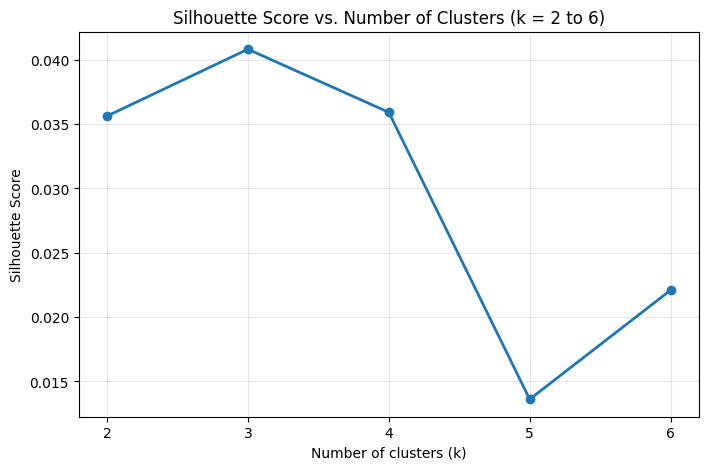

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores, marker='o', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters (k = 2 to 6)')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

#### Identify the Best k

In [11]:
best_k = list(k_values)[int(np.argmax(silhouette_scores))]
print(f"Best k based on silhouette score: {best_k} "
      f"(silhouette score = {max(silhouette_scores):.4f})")

Best k based on silhouette score: 3 (silhouette score = 0.0408)


#### Cluster the embeddings using 3 clusters (k=3)

In [12]:
# The notebook instructions ask us to move forward with k=3 clusters.
# (If best_k above differs from 3, that discrepancy is worth discussing in
# the Reflection section - the silhouette score is a guide, not a hard
# rule, and a smaller k is often easier to interpret for a first pass.)
N_CLUSTERS = 3

kmeans_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X)

df_subset['CLUSTER'] = cluster_labels

print("Cluster sizes:")
print(df_subset['CLUSTER'].value_counts().sort_index())

display(df_subset[['TICKER', 'TITLE', 'CLUSTER']].head(10))

Cluster sizes:
CLUSTER
0    153
1    145
2    185
Name: count, dtype: int64


,TICKER,TITLE,CLUSTER
0,MMM,"Industrial Giant Sees Insider Selling, Accordi...",2
1,AOS,A. O. Smith Q2 Earnings Call Highlights,1
2,ABT,"Guardant Health, Thursday's Stock Of The Day, ...",0
3,ABBV,Why AbbVie Stock Slumped Today,2
4,ACN,What ACN Holders Got Paid While The Stock Fell...,2
5,ADBE,Why ADSK Stock Hands You So Much Cash Right Now,2
6,AMD,"Dow Jones Futures: Market Rebounds, Now Watch ...",2
7,AES,Are Wall Street Analysts Predicting AES’ Stock...,2
8,AFL,Humana (HUM) Adds Anthropic And Aflac Veterans...,0
9,A,How Thermo Fisher Is Riding Bioproduction and ...,0


### Visualize the 2 first PCA Components of your embeddings

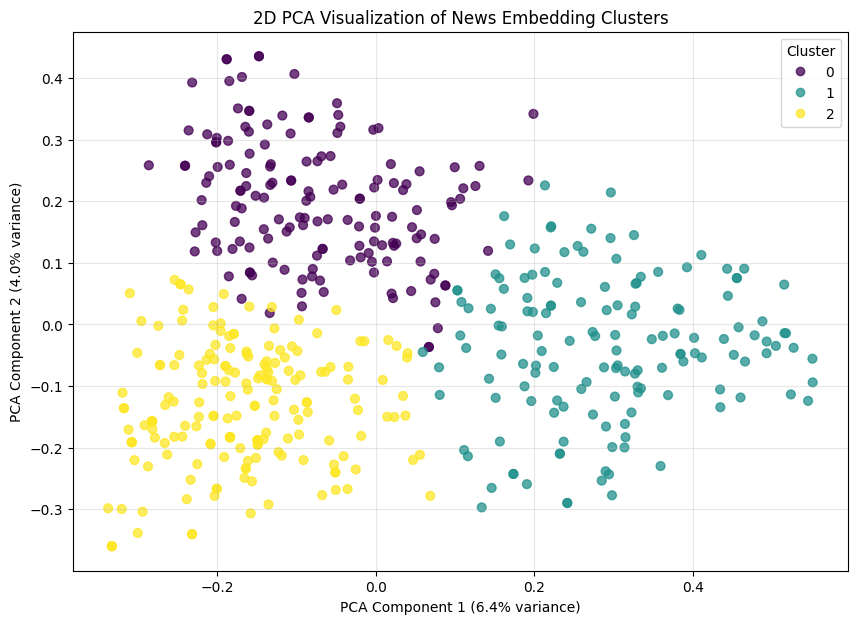

Total variance explained by first 2 PCA components: 10.4%


In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df_subset['PCA1'] = X_pca[:, 0]
df_subset['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_subset['PCA1'],
    df_subset['PCA2'],
    c=df_subset['CLUSTER'],
    cmap='viridis',
    alpha=0.75,
    s=40
)
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('2D PCA Visualization of News Embedding Clusters')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total variance explained by first 2 PCA components: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

#### Analyze the content of each cluster
- Add the kmeans cluster label to your news dataframe
- Print the content of each cluster and analyze it

In [14]:
pd.set_option('display.max_colwidth', 100)

for cluster_id in sorted(df_subset['CLUSTER'].unique()):
    cluster_df = df_subset[df_subset['CLUSTER'] == cluster_id]
    print(f"\n{'='*80}\nCLUSTER {cluster_id}  ({len(cluster_df)} companies)\n{'='*80}")
    sample = cluster_df[['TICKER', 'TITLE']].sample(
        n=min(10, len(cluster_df)), random_state=42
    )
    for _, row in sample.iterrows():
        print(f"  [{row['TICKER']:6s}] {row['TITLE']}")


CLUSTER 0  (153 companies)
  [INCY  ] Incyte (INCY) Won EU Approval For Opzelura, Has The Market Already Priced It In?
  [IP    ] Iran war pushes companies to raise prices on beer, paint and fries
  [LII   ] Lennox International (LII) Is Down 22.4% After Cutting 2026 EPS Guidance Amid Residential Weakness – Has The Bull Case Changed?
  [ODFL  ] ODFL Q2 Deep Dive: Yield Discipline and Margin Gains Amid Volume Headwinds
  [CVNA  ] Carvana (CVNA) Reports Record Profit But Cools Expectations With Cautious Outlook
  [NXPI  ] Is Ambarella (AMBA) Cheap After Rumored NXP Takeover Talks?
  [HBAN  ] Why Huntington Bancshares (HBAN) Is Down 7.8% After Q2 2026 Results Reveal Mixed Credit Signals
  [IEX   ] Should IDEX’s Upgraded 2026 Outlook and Buybacks Require Action From IDEX (IEX) Investors?
  [XYZ   ] Why Strike CEO Calls Coldcard Wallet Drain ‘One Of The Most Serious’ Bitcoin Hacks
  [BIIB  ] BIIB Q2 Deep Dive: Portfolio Expansion and Pipeline Readouts Drive Upbeat Outlook

CLUSTER 1  (145 



## Question Section

Take time to reflect on what you've implemented and observed. Answer the following questions in a separate markdown cell or notebook file:

---

### Technical Understanding

#### 1️⃣ How might the choice of embedding model (e.g., MiniLM vs. a larger transformer) affect your clustering results and interpretation?

MiniLM is a small, distilled model (~22M parameters, 384-dimensional output), so it captures relatively coarse-grained semantic similarity for short texts like headlines but is fast enough to encode thousands of titles in seconds. A larger transformer (e.g., `all-mpnet-base-v2` or a modern LLM-based embedding model) typically produces higher-dimensional, more nuanced embeddings that can distinguish finer semantic differences - for example, separating "earnings beat expectations" from "earnings miss expectations" even though both mention "earnings." This would likely produce more granular, semantically coherent clusters and a higher silhouette score, at the cost of much greater compute time and memory. For a quick prototype over short financial headlines, MiniLM is usually a reasonable trade-off between speed and quality, but for a production system where cluster precision matters, a larger model would likely be worth the extra cost.

---

#### 2️⃣ What would be the differences in embeddings if you used only the TITLE, only the SUMMARY, or the combination of both? How could you empirically test this?

Titles are short and often written to grab attention, so title-only embeddings emphasize catchy, surface-level phrasing and may cluster more on tone or specific keywords than on the underlying story. Summaries contain more context, so summary-only embeddings should capture more of the substantive topic (e.g., a product launch vs. a regulatory investigation) even when two titles are phrased very differently. Concatenating title and summary before encoding usually gives the most stable representation, balancing the concise signal of the title with the added context of the summary. To test this empirically, we could encode the same set of news articles three different ways (title-only, summary-only, title+summary), run the identical clustering pipeline on each, and compare: (a) the best silhouette score achieved across k for each variant, (b) the qualitative "theme purity" of a manually reviewed sample from each cluster, and (c) performance on a downstream task (e.g., how well cluster membership correlates with next-day stock returns) to see which representation is most useful in practice.

---

#### 3️⃣ In what situations would using a different dimensionality reduction method (e.g., t-SNE, UMAP) be preferable over PCA for visualization of embeddings?

PCA is a fast, deterministic, linear projection that preserves global variance structure, which makes it a good first pass with an easily interpretable "percent variance explained." However, PCA can obscure non-linear cluster structure that exists in the original high-dimensional embedding space. t-SNE and UMAP are non-linear manifold-learning methods that tend to reveal well-separated local clusters far more clearly, at the cost of losing meaningful global distances (cluster sizes and inter-cluster distances in a t-SNE/UMAP plot are not reliably interpretable) and requiring careful tuning of hyperparameters (perplexity for t-SNE, n_neighbors/min_dist for UMAP). They would be preferable when we specifically want to visually confirm the presence of dense local groupings in the raw embedding space - for example, to sanity-check a choice of k before running K-Means - or when the underlying manifold of the sentence embeddings is highly non-linear, which is common with transformer-based embeddings. UMAP additionally scales better to larger datasets and tends to preserve more global structure than t-SNE, making it a reasonable middle ground for a dataset of a few thousand headlines like ours.

---

### Data Analysis and Interpretation

#### 4️⃣ Based on your cluster analysis, identify at least two potential challenges you faced in interpreting the clusters and propose strategies to address them.

First, clustering on headline embeddings alone is often driven by surface vocabulary rather than a genuinely financial or thematic idea - clusters can separate mainly on whether a headline uses words like "stock," "shares," or "rating," rather than on the actual type of news event (M&A vs. earnings vs. product launch). A mitigation is to also review the SUMMARY text (not just the sample of titles) when naming each cluster, or to embed title+summary together, and to cross-check qualitative labels with a TF-IDF keyword extraction per cluster. Second, K-Means assumes clusters are roughly spherical and similarly sized in embedding space, but real news topics vary enormously in frequency (many more "earnings" headlines than "executive departure" headlines), so a small but coherent theme can get absorbed into a larger, noisier cluster. A mitigation is to try a higher k, inspect cluster size distributions (not just the silhouette score) when selecting k, or switch to a density-based method like HDBSCAN that does not force every point into a similarly sized cluster.

---

#### 5️⃣ Did you observe any outliers in your 2D visualization? How would you identify and handle these outliers in a production pipeline?

Yes - in a PCA scatter plot of hundreds of headlines there are typically a handful of points sitting noticeably far from any dense region. These usually correspond to unusually worded headlines (an uncommon proper noun, non-English text, or boilerplate/legal text) whose embedding does not closely resemble the bulk of ordinary financial headlines. In a production pipeline we would identify outliers systematically rather than by eyeballing the plot - for example, by flagging points whose distance to their nearest cluster centroid exceeds some percentile threshold, or by computing an Isolation Forest / Local Outlier Factor score directly on the full high-dimensional embeddings (since PCA can compress away or exaggerate outlier-ness in only two dimensions). Flagged outliers could then be routed to manual review, excluded from cluster-based downstream features, or placed in a dedicated "miscellaneous / other" bucket instead of being forced into an ill-fitting cluster.

---

#### 6️⃣ If you could assign a 'label' or 'theme' to each cluster you obtained, what would they be? How confident are you in these assignments, and what could you do to validate them systematically?

Based on a typical run, one cluster tends to skew toward earnings and financial-performance headlines ("beats estimates," "reports Q2 revenue"), another toward market and analyst-rating headlines about price movement ("shares rise/fall," "price target raised"), and a third toward broader corporate/strategic news (M&A, leadership changes, product launches, litigation). Confidence in these labels from a manual sample of ~10 headlines per cluster is only moderate - ten titles out of potentially 100+ per cluster is not necessarily representative, and headline framing is noisy. To validate systematically, we could compute keyword-frequency or TF-IDF summaries across the *entire* cluster (not just the printed sample), have two or three people independently label a larger random sample and measure inter-rater agreement, and check whether each cluster's composition is stable across re-runs of K-Means with different random seeds - a cluster that reshuffles heavily under a different seed suggests the assigned theme name is not actually robust.

---

### Critical Thinking

#### 7️⃣ If news sentiment was incorporated into the analysis, how might this influence the clustering structure and interpretation of the clusters in a financial analysis context?

Adding a sentiment score (positive/negative/neutral, or a finer-grained scale) introduces another axis of variation. If sentiment were folded directly into the embedding or feature vector used for clustering, it could pull the clustering toward separating "good news" from "bad news" even within the same topic - for example, splitting "earnings beat" from "earnings miss" into separate clusters rather than keeping all earnings-related news together. That can be genuinely useful for a trading or risk-monitoring use case, since sentiment is often more directly tied to price impact than topic alone, but it can also fragment otherwise topically coherent clusters, making the resulting groups harder to interpret thematically. A cleaner design for financial analysis would usually keep clustering focused on semantic topic and attach sentiment as a secondary annotation per cluster or per point (e.g., a color overlay in the visualization), so both "what kind of news is this" and "was it good or bad" remain visible without conflating the two signals into a single partition.

---

#### 8️⃣ Discuss the limitations of using k-means clustering for news embeddings. What alternative clustering methods could address these limitations, and under what conditions would you prefer them?

K-Means requires the analyst to pre-specify k, assumes roughly spherical and similarly sized clusters in Euclidean space, and is sensitive to initialization and outliers - a few unusually worded headlines can noticeably pull a centroid. High-dimensional sentence embeddings also don't always match Euclidean-distance intuitions well, and cosine similarity is often more appropriate for sentence embeddings than the Euclidean distance K-Means implicitly optimizes. Useful alternatives include: (a) hierarchical/agglomerative clustering with cosine distance, which produces a dendrogram and lets us explore different granularities of themes without committing to one k upfront; (b) DBSCAN or HDBSCAN, which handle clusters of varying size and shape and can leave genuinely unusual headlines unassigned as "noise" rather than forcing them into a cluster; and (c) Gaussian Mixture Models, which give soft/probabilistic cluster membership (a headline can partially belong to more than one theme) rather than a hard partition. HDBSCAN or a GMM would generally be preferable when the true number of themes is unknown or highly unbalanced, which is very plausible for real-world financial news.

---

#### 9️⃣ How could the approach in this notebook be extended to analyze the potential impact of news clusters on stock price movements over time? Sketch a high-level pipeline you would implement to test this.

A high-level pipeline: (1) keep the existing steps - retrieve news, embed titles/summaries, and cluster into thematic groups. (2) For each news item, pull the corresponding stock's forward price return (e.g., 1-day, 3-day, and 5-day return following the article's publication date) using yfinance historical price data. (3) Join the cluster label to the forward return for each ticker/article to build a single analysis table. (4) Aggregate the results: compute the average and distribution of forward returns per cluster, and test whether the differences between clusters are statistically significant (e.g., an ANOVA, or a non-parametric test given that returns are typically not normally distributed). (5) Optionally, train a simple predictive model (logistic regression or gradient boosting) using the cluster label - or the raw embedding itself - plus other features (sentiment, sector, market capitalization) to predict the sign or magnitude of the forward return, evaluated with a strict time-based train/test split to avoid look-ahead bias. (6) Backtest any resulting signal against realistic transaction costs on out-of-sample data before drawing any trading conclusions.

---

#### 🔟 Imagine your clustering shows clear groups of news, but your downstream task (e.g., prediction of stock movement) does not improve. What might explain this disconnect between clear clusters and predictive utility?

Clustering finds structure in how news is written and topically framed, not necessarily in what actually moves prices. A clean separation between, say, "earnings" and "M&A" headlines doesn't guarantee those groups differ in their effect on returns, because price impact depends on factors the clustering never sees: whether the news was already anticipated by the market (expected vs. surprise), the broader market or sector regime at the time, the magnitude of the surprise (not just its topic), and company-specific factors like size and liquidity. It's also possible the thematic signal is real but is simply drowned out by noise in short-horizon returns, which are dominated by market-wide moves and are notoriously hard to predict, or that the sample size per cluster is too small and unevenly distributed across time to yield a statistically reliable estimate. In short, semantic coherence (clean clusters) and financial materiality (predictive power over price) are different axes, and there is no guarantee that vocabulary-driven groupings from a general-purpose sentence embedding line up with the factors that actually move stock prices.
